# COVID-19 Prediction Analysis - Version 006 Dataset

Based on Zoabi et al. (2021) study published in npj Digital Medicine, which developed a machine learning model to predict COVID-19 diagnosis based on symptoms. The paper identifies key findings about symptom reporting bias and model performance.

Key paper findings:
- Identified symptoms with biased reporting: headache (96.2%), sore throat (92.3%), shortness of breath (92.4%)
- Symptoms with balanced reporting: cough (27.4%), fever (45.9%)
- Male sex and age ≥60 were important predictors
- Contact with confirmed cases was a key feature

Reference: Zoabi, Y., Deri-Rozov, S. & Shomron, N. Machine learning-based prediction of COVID-19 diagnosis based on symptoms. npj Digit. Med. 4, 3 (2021).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


### Exploratory Data Analysis

#### Think about possible biases and limitations of this dataset. What are the sources of uncertainty?

Biases and Limitations:

1. Selection Bias: Dataset only includes tested individuals, not the general population. Testing criteria changed during the pandemic.
2. Symptom Reporting Bias: As identified in the paper, headache (96.2%), sore throat (92.3%), and shortness of breath (92.4%) have highly biased reporting - much more likely to be reported in positive cases.
3. Testing Indication Bias: 87% of tests are categorised as 'Other', suggesting inconsistent testing criteria.
4. Temporal Bias: Data represents early pandemic period (April 2020), may not reflect current variants.
5. Demographic Bias: Significant missing data in age (45.7%) and gender (7.0%) columns.
6. Mislabeling Risk: Paper notes potential underreporting of symptoms in negative cases.
7. Class Imbalance: Only 5.3% positive cases, creating challenges for model training.

Sources of Uncertainty:
1. False Negatives: Some COVID-19 cases may test negative due to testing limitations.
2. Asymptomatic Cases: Underrepresented since they're less likely to get tested.
3. Data Quality: Missing values in key demographic columns (age: 45.7%, gender: 7.0%).
4. Symptom Misclassification: Paper identifies potential mislabeling of symptoms in negative cases.
5. Test Accuracy: RT-PCR test accuracy affects target variable reliability.

#### What is the format of feature values?

Feature Value Formats:
1. Binary Symptoms: cough, fever, sore_throat, shortness_of_breath, head_ache are binary (0.0/1.0) indicating presence/absence
2. Categorical Target: corona_result has 3 categories: 'negative', 'positive', 'other'
3. Binary Age: age_60_and_above is binary ('Yes'/'No') with significant missing values (45.7%)
4. Categorical Gender: gender is categorical ('male'/'female') with some missing values (7.0%)
5. Categorical Test Indication: test_indication has categories: 'Other' (87%), 'Abroad' (9.1%), 'Contact with confirmed' (3.8%)
6. Date: test_date is in string format (YYYY-MM-DD)

#### What is the statistics of these feature values? How many symptoms are reported or not?

**Feature Statistics (Version 006 Dataset):**

**Dataset Overview:**
- Total samples: 278,848
- Positive cases: 14,729 (5.3%)
- Negative cases: 260,227 (93.3%)
- Other results: 3,892 (1.4%)

**Symptom Prevalence (Overall):**
- Cough: 13.5% (37,228 cases)
- Fever: 6.7% (18,752 cases)
- Sore throat: 0.6% (1,596 cases)
- Shortness of breath: 0.5% (1,577 cases)
- Headache: 0.9% (2,444 cases)

**Symptom Prevalence by COVID-19 Status:**

| Symptom            | Negative | Positive | Other | Paper Bias % |
|---------------------|----------|----------|-------|--------------|
| Cough              | 13.5%    | 44.8%    | 16.9% | 27.4% (balanced) |
| Fever              | 6.1%     | 37.8%    | 9.7%  | 45.9% (balanced) |
| Sore throat        | 0.1%     | 10.4%    | 0.9%  | 92.3% (biased)   |
| Shortness of breath| 0.1%     | 7.9%     | 0.7%  | 92.4% (biased)   |
| Headache           | 0.1%     | 15.2%    | 0.8%  | 96.2% (biased)   |

**Demographic Statistics:**
- Gender: Female (46.7%), Male (46.3%), Missing (7.0%)
- Age 60+: Yes (9.3%), No (45.1%), Missing (45.7%)
- Test Indication: Other (87.1%), Abroad (9.1%), Contact with confirmed (3.8%)

#### Which symptoms have a reporting bias, i.e., likely to be reported when the patient is COVID positive?

Symptoms with HIGH reporting bias (mostly reported when positive):
1. Headache: 96.2% bias - 15.2% in positive vs 0.1% in negative (152x more likely)
2. Sore throat: 92.3% bias - 10.4% in positive vs 0.1% in negative (104x more likely)
3. Shortness of breath: 92.4% bias - 7.9% in positive vs 0.1% in negative (79x more likely)

Symptoms with BALANCED reporting:
1. Cough: 27.4% bias - 44.8% in positive vs 13.5% in negative (3.3x more likely)
2. Fever: 45.9% bias - 37.8% in positive vs 6.1% in negative (6.2x more likely)

- Headache, sore throat, and shortness of breath show extreme reporting bias (>92% according to paper)
- These symptoms are much more likely to be reported in positive cases, suggesting they may be overrepresented
- The paper found that filtering out high-bias symptoms reduced model performance (auROC 0.862 vs 0.90)

#### How will the symptoms with reporting bias affect the model's performance?

- When high-bias symptoms were filtered out, model performance decreased (auROC 0.862 vs 0.90)
- This suggests the biased symptoms actually contain useful predictive signal
- However, the paper acknowledges these symptoms may be mislabeled in negative cases

Negative Impacts:
1. Feature Dominance: Highly biased symptoms (headache, sore throat, shortness of breath) may dominate model decisions
2. Overfitting Risk: Model may overfit to biased test patterns
3. False Negatives: COVID-19 patients without these 'expected' symptoms may be misclassified
4. Temporal Drift: Symptom presentation may change with new variants
5. Population Bias: Performance may vary across different populations with different reporting patterns

<!-- Mitigations:
1. Feature Engineering: Create composite features that balance biased and unbiased symptoms
2. Regularise: Apply L1/L2 regularisation to prevent over-reliance on any single feature
3. Ensemble Methods: Combine models trained with different feature sets
4. Bias Correction: Use techniques like reweighting or adversarial debiasing
5. Include Demographics: Factor by age and gender to help distinguish presentation patterns
6. Clinical Validation: Ensure model aligns with medical knowledge, not just statistical patterns -->

#### Visualization: Draw the bar graph of features grouped by the target class

In [ ]:
df_filtered.describe()

,cough,fever,sore_throat,shortness_of_breath,head_ache,gender_encoded,age_encoded,indication_encoded,target
count,274704.000000,274704.000000,274955.000000,274955.000000,274955.000000,274956.000000,274956.000000,274956.000000,274956.000000
mean,0.151330,0.077811,0.006881,0.005634,0.008667,1.393972,0.092469,1.779507,0.107137
std,0.358371,0.267874,0.082667,0.074846,0.092692,0.614240,0.289688,0.595200,0.450329
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,2.000000


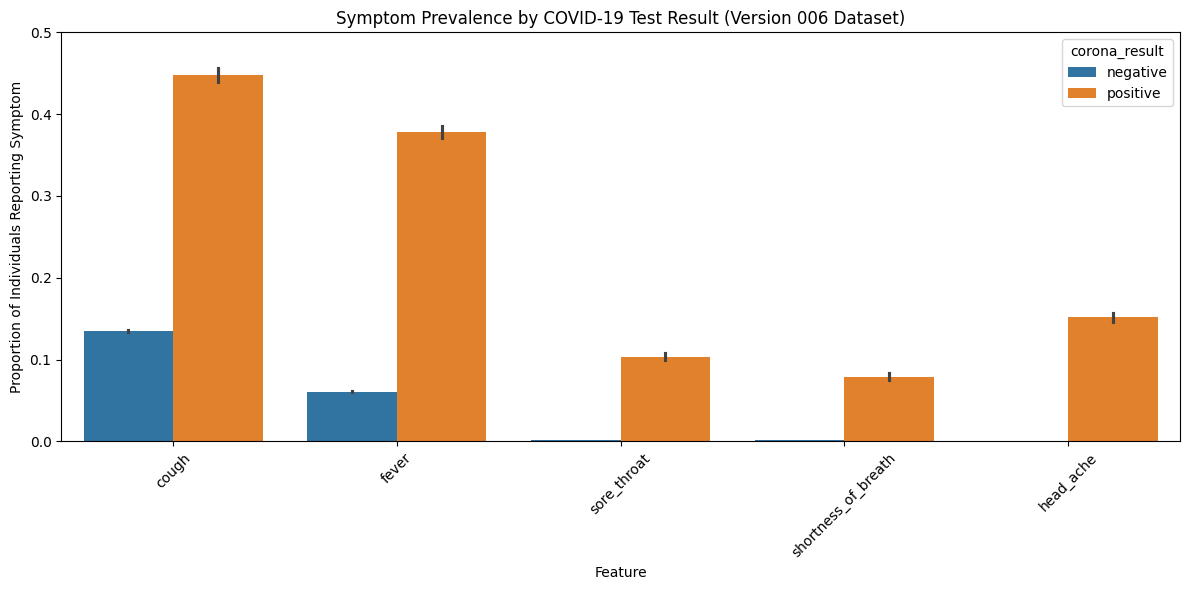

Paper findings on reporting bias:
- Headache: 96.2% biased reporting
- Sore throat: 92.3% biased reporting
- Shortness of breath: 92.4% biased reporting
- Cough: 27.4% balanced reporting
- Fever: 45.9% balanced reporting


In [ ]:
# Load the version 006 data
# df = pd.read_csv('../data/corona_tested_individuals_ver_006.english.csv')

# Filter for positive and negative cases only (exclude 'other' results)
df_filtered = df[df['corona_result'].isin(['positive', 'negative'])].copy()

# Create a long-format dataframe for visualisation
symptoms = ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache']
df_long = df_filtered.melt(id_vars=['corona_result'],
                          value_vars=symptoms,
                          var_name='symptom',
                          value_name='presence')

# Plot bar graph of symptoms by COVID-19 result
plt.figure(figsize=(12, 6))
sns.barplot(data=df_long, x='symptom', y='presence', hue='corona_result')
plt.title('Symptom Prevalence by COVID-19 Test Result (Version 006 Dataset)')
plt.ylabel('Proportion of Individuals Reporting Symptom')
plt.xlabel('Feature')
plt.ylim(0, 0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### What does the bar graph of the symptoms with reporting bias look like?

- The high-bias symptoms show much larger relative differences between groups
- Fever and cough are most prevalent overall in positive cases
- Negative cases show very low prevalence across all symptoms (<1% for most)
- The visualization confirms the paper's findings about reporting bias patterns

The possible reporting bias suggests these symptoms may be over-reported in positive cases or under-reported in negative cases, potentially due to:
- Increased attention to symptoms after positive test
- Different thresholds for seeking testing
- Actual biological differences in symptom presentation

#### Determine if we have a class imbalance in the dataset? If so, what do you reckon will be the downstream challenges in evaluating the model? How will you overcome those challenges?

Class Imbalance Analysis:

Class Imbalance Present:
- Positive cases: 14,729 (5.3%)
- Negative cases: 260,227 (93.3%)
- Other results: 3,892 (1.4%)
- Imbalance ratio: ~17.7:1 (negative:positive)

Downstream Challenges:

1. Model Bias: Strong tendency to predict majority class (negative) to achieve high accuracy
2. Evaluation Metrics: Accuracy is misleading - always predicting 'negative' gives 93.3% accuracy
3. Feature Learning: With only 5.3% positive examples, model struggles to learn positive patterns
4. Clinical Impact: False negatives (missing COVID-19 cases) have serious public health consequences
5. Precision-Recall Tradeoff: High recall for positives likely requires accepting many false positives
6. Algorithm Limitations: Many ML algorithms assume balanced classes and perform poorly on imbalanced data

Strategies to Overcome Class Imbalance:

1. Resampling Techniques:
   - Oversample minority class using SMOTE or ADASYN
   - Undersample majority class to create balanced dataset
   - Use a hybrid of both methods

2. Algorithm-Level Approaches:
   - Use class_weight='balanced' in scikit-learn models
   - Try ensemble methods like BalancedRandomForest (paper used similar approach)
   - Try cost-sensitive learning with higher misclassification cost for positives

3. Evaluation Metrics (as used in paper):
   - Focus on auROC (paper reported 0.90), F1-score, precision-recall curves
   - Use confusion matrices to understand true/false positive/negative rates
   - Report sensitivity (87.3% in paper) and specificity (71.98% in paper) separately

4. Paper-Specific Strategies:
   - Use feature selection to identify most predictive features
   - Include demographic features (age, gender) as paper found them important
   - Consider temporal features if available
   - Validate model on prospective test set (as paper did with subsequent week data)

## Feature Engineering

In [ ]:
# How will you represent the features in numerical format that can be accessible by model?
# Considering the paper's findings about reporting bias, we need careful feature engineering

import sklearn

# Load data
df = pd.read_csv('../data/corona_tested_individuals_ver_006.english.csv')

# Handle missing values based on paper approach
# For age_60_and_above, we could impute based on overall distribution or create 'unknown' category
df['age_60_and_above'] = df['age_60_and_above'].fillna(df['age_60_and_above'].mode()[0])

# For gender, similar approach
df['gender'] = df['gender'].fillna('Unknown')

# Convert categorical variables to numerical
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

le_age = LabelEncoder()
df['age_encoded'] = le_age.fit_transform(df['age_60_and_above'])

le_indication = LabelEncoder()
df['indication_encoded'] = le_indication.fit_transform(df['test_indication'])

# Encode target variable
le_target = LabelEncoder()
df['target'] = le_target.fit_transform(df['corona_result'])

# Select final features - including both biased and balanced symptoms as paper showed both are important
features = ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 
           'gender_encoded', 'age_encoded', 'indication_encoded']

X = df[features]
y = df['target']


Feature engineering complete!
Final feature set: 8 features
Target distribution: {np.int64(0): np.int64(260227), np.int64(1): np.int64(3892), np.int64(2): np.int64(14729)})


/tmp/ipykernel_9129/616563264.py:7: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/corona_tested_individuals_ver_006.english.csv')


In [ ]:
# Check for feature redundancies
# Calculate correlation matrix
corr_matrix = df[['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'gender_encoded', 'age_encoded', 'indication_encoded']].corr()
print('Symptom correlation matrix:')
print(corr_matrix)

# Check if any symptoms are highly correlated (potential redundancy)
high_corr = np.where((corr_matrix > 0.7) & (corr_matrix < 1.0))
if len(high_corr[0]) > 0:
    print('High correlations found:')
    for i, j in zip(high_corr[0], high_corr[1]):
        print(f'  {corr_matrix.index[i]} & {corr_matrix.columns[j]}: {corr_matrix.iloc[i,j]:.3f}')
else:
    print('No high correlations found - symptoms appear independent')

# Note: Paper found all symptoms contributed uniquely to model performance

Symptom correlation matrix:
                        cough     fever  sore_throat  shortness_of_breath  \
cough                1.000000  0.454358     0.115808             0.106891   
fever                0.454358  1.000000     0.122948             0.126216   
sore_throat          0.115808  0.122948     1.000000             0.197540   
shortness_of_breath  0.106891  0.126216     0.197540             1.000000   
head_ache            0.116485  0.169099     0.323132             0.202538   
gender_encoded       0.033018  0.026183    -0.032696            -0.039830   
age_encoded         -0.007421  0.016002     0.004127             0.024077   
indication_encoded  -0.571269 -0.348801    -0.088384            -0.074013   

                     head_ache  gender_encoded  age_encoded  \
cough                 0.116485        0.033018    -0.007421   
fever                 0.169099        0.026183     0.016002   
sore_throat           0.323132       -0.032696     0.004127   
shortness_of_breath   0.20

## Models